In [1]:
from __future__ import annotations
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Tuple

# Japan Image Augmentation

## Images used

- Shibuya Crossing (Night) https://www.pexels.com/photo/vibrant-shibuya-crossing-at-night-in-tokyo-30429425/
- Cherry Blossoms https://thursd.com/articles/cherry-blossom-tree
- The Great Wave (Ukiyo‑e Woodblock Print) https://www.metmuseum.org/essays/art-of-the-pleasure-quarters-and-the-ukiyo-e-style

## Helpers

In [2]:
def show_pair(a, b, titles=("Original", "Augmented"), figsize=(10,5)):
    plt.figure(figsize=figsize)
    plt.subplot(1,2,1)
    plt.imshow(a)
    plt.title(titles[0])
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.imshow(b)
    plt.title(titles[1])
    plt.axis('off')
    plt.show()

In [3]:
def load_rgb(path: str, dummy: bool=False, size: tuple[int,int]=(720,1080)) -> np.ndarray:
    if os.path.exists(path) and not dummy:
        img_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
        if img_bgr is None:
            dummy = True
        else:
            return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    # dummy: colorful gradient + noise
    h, w = size
    y = np.linspace(0, 1, h)[:,None]
    x = np.linspace(0, 1, w)[None,:]
    r = x
    g = y
    b = 1 - 0.5*(x+y)
    img = np.stack([r,g,b], axis=2)
    img += 0.05*np.random.RandomState(42).randn(h,w,3)
    img = np.clip(img, 0, 1)
    return (img*255).astype(np.uint8)

In [4]:
def save_rgb(path: str, img_rgb: np.ndarray):
    bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(path, bgr)

## Day 1

#### Use Case (Japan)
Enhance a night-time urban scene (**Shibuya Crossing**) and adapt a seasonal nature scene (**Cherry Blossoms**) to classical Japanese art aesthetics (**Ukiyo-e**) using **non-geometric** image augmentations.

#### Problem
Night scenes often suffer from low local contrast; we also want a stylized palette that evokes traditional woodblock prints without using ML/DL or any geometric transforms.

#### How (Methods)
- CLAHE on L* channel in Lab for locally adaptive contrast control.
- Fourier high‑boost sharpening to reinforce mid‑high‑frequency details.
- Reinhard color transfer from Ukiyo‑e reference to photo for stylistic palette mapping.

#### Why (Rationale)
- **Lab-space CLAHE** enhances luminance (L\*) while preserving chroma (a\*, b\*), avoiding hue shifts common with naive RGB equalization.
- **Reinhard transfer** aligns first- and second-order color statistics in a perceptual space, yielding a Ukiyo-e-like palette without learning.
- **Frequency-domain high-boost** gives print-like crispness with tunable control and no geometry changes.

#### What (Scope)
1. **Shibuya Crossing (Night):** CLAHE → FFT high-boost.
2. **Cherry Blossoms:** Reinhard color transfer using the Ukiyo-e print as reference.
3. **Ukiyo-e Woodblock Print:** Used as the **style source**

### Load Data

In [5]:
Path('outputs').mkdir(exist_ok=True)

In [6]:
SRC_SHIBUYA = 'Data/ShibuyaCrossingNight.png'
SRC_SAKURA  = 'Data/CherryBlossoms.png'
SRC_UKIYOE  = 'Data/TheGreatWave.png'

In [7]:
img_shibuya = load_rgb(SRC_SHIBUYA)
img_sakura  = load_rgb(SRC_SAKURA)
img_ukiyoe  = load_rgb(SRC_UKIYOE)

In [8]:
Path('images').mkdir(exist_ok=True)

save_rgb('images/shibuya.jpg', img_shibuya)
save_rgb('images/sakura.jpg', img_sakura)
save_rgb('images/ukiyoe.jpg', img_ukiyoe)

In [9]:
print("Loaded images from /mnt/data and saved copies under images/:")

print(" - Shibuya:", img_shibuya.shape)
print(" - Sakura:",  img_sakura.shape)
print(" - Ukiyoe:",  img_ukiyoe.shape)

Loaded images from /mnt/data and saved copies under images/:
 - Shibuya: (2700, 1519, 3)
 - Sakura: (1000, 780, 3)
 - Ukiyoe: (807, 1200, 3)


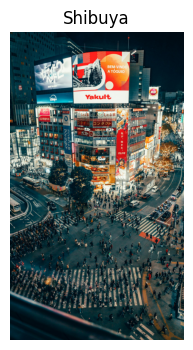

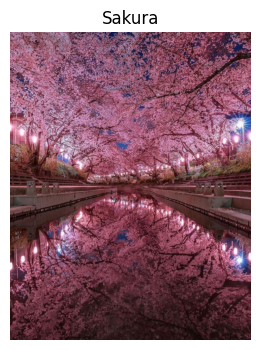

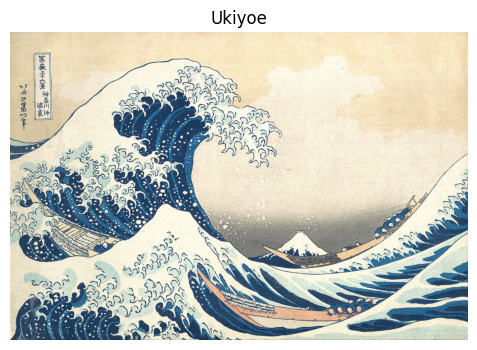

In [10]:
plt.figure(figsize=(6,4)); plt.imshow(img_shibuya); plt.title("Shibuya"); plt.axis("off"); plt.show()
plt.figure(figsize=(6,4)); plt.imshow(img_sakura);  plt.title("Sakura");  plt.axis("off"); plt.show()
plt.figure(figsize=(6,4)); plt.imshow(img_ukiyoe);  plt.title("Ukiyoe");  plt.axis("off"); plt.show()

### Sample Image

In [11]:
def sample_ramp(size: Tuple[int,int]=(720,1080)) -> np.ndarray:
    H, W = size
    img = np.ones((H, W, 3), np.uint8) * 200
    x = np.linspace(0, 1, W, dtype=np.float32)
    ramp = (120 + 25*(x - 0.5)).clip(0,255)
    ramp = np.tile(ramp, (H,1)).astype(np.uint8)
    out = np.stack([ramp, ramp, ramp], axis=2)
    for y in range(80, H, 80):
        cv2.putText(out, "CLAHE?", (20, y), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (150,150,150), 1, cv2.LINE_AA)
    return out

In [12]:
def sample_color_patches(size: Tuple[int,int]=(720,1080)) -> np.ndarray:
    H, W = size
    img = np.ones((H, W, 3), np.uint8) * 240
    cols = [
        (255, 0, 0), (0, 255, 0), (0, 0, 255),
        (255,255,0), (0,255,255), (255,0,255),
        (200,160,120), (160,120,200), (120,200,160)
    ]
    pad = 30
    box = (H - 2*pad) // 3
    x0 = pad; y0 = pad
    for r in range(3):
        for c in range(3):
            x1 = x0 + c*(box+pad)
            y1 = y0 + r*(box+pad)
            cv2.rectangle(img, (x1,y1), (x1+box, y1+box), cols[r*3+c], -1)
    return img

In [13]:
def sample_gratings(size: Tuple[int,int]=(720,1080)) -> np.ndarray:
    H, W = size
    img = np.zeros((H, W), np.uint8) + 180
    rows = 6
    for i in range(rows):
        y0 = i*(H//rows)
        y1 = (i+1)*(H//rows)
        freq = 2**i
        x = np.arange(W)
        sine = (127.5*(1 + np.sin(2*np.pi*freq*x/W))).astype(np.uint8)
        img[y0:y1, :] = sine
    # hard/soft edges at top
    cv2.rectangle(img, (20, 20), (W-20, 40), 0, -1)
    cv2.rectangle(img, (20, 50), (W-20, 70), 255, -1)
    bar = np.zeros((30, W-40), np.uint8); bar[:, :(W-40)//2] = 255
    bar = cv2.GaussianBlur(bar, (0,0), 3)
    img[80:110, 20:W-20] = bar
    rgb = np.stack([img,img,img], axis=2)
    return rgb

In [14]:
img_ramp = sample_ramp()
img_patches = sample_color_patches()
img_gratings = sample_gratings()

In [15]:
save_rgb('images/sample_ramp.png', img_ramp)
save_rgb('images/sample_patches.png', img_patches)
save_rgb('images/sample_gratings.png', img_gratings)

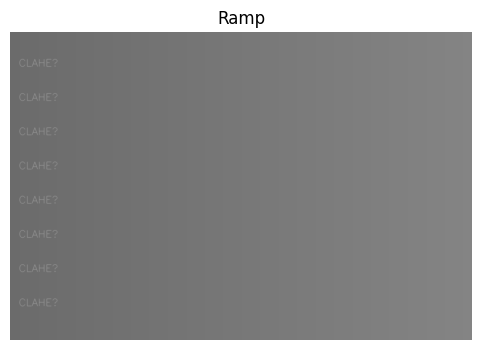

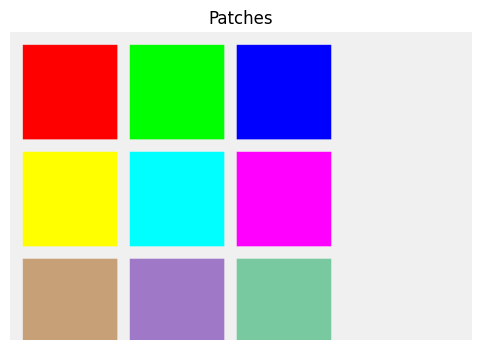

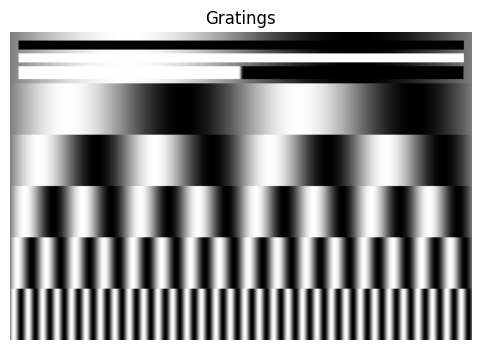

In [16]:
plt.figure(figsize=(6,4)); plt.imshow(img_ramp); plt.title("Ramp"); plt.axis("off"); plt.show()
plt.figure(figsize=(6,4)); plt.imshow(img_patches);  plt.title("Patches");  plt.axis("off"); plt.show()
plt.figure(figsize=(6,4)); plt.imshow(img_gratings);  plt.title("Gratings");  plt.axis("off"); plt.show()

### Contrast Limited Adaptive Histogram Equalization (CLAHE)

In [17]:
def clahe_lab(rgb: np.ndarray, clip_limit: float=2.5, tile_grid_size=(8,8)) -> np.ndarray:
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    L, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    L2 = clahe.apply(L)
    lab2 = cv2.merge([L2, a, b])
    out = cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)
    return out

#### Sample Image Test

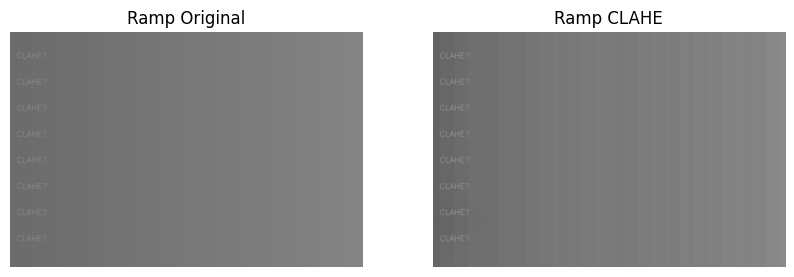

In [18]:
ramp_clahe = clahe_lab(img_ramp, clip_limit=2.5, tile_grid_size=(8,8))
save_rgb('outputs/sample_ramp_CLAHE.jpg', ramp_clahe)
show_pair(img_ramp, ramp_clahe, ("Ramp Original", "Ramp CLAHE"))

#### Run on Japan Image

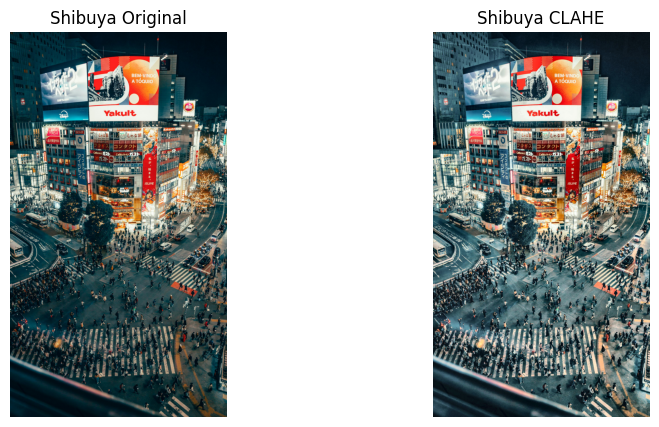

In [19]:
shibuya_clahe = clahe_lab(img_shibuya, clip_limit=2.5, tile_grid_size=(8,8))
save_rgb('outputs/shibuya_CLAHE.jpg', shibuya_clahe)
show_pair(img_shibuya, shibuya_clahe, ("Shibuya Original", "Shibuya CLAHE"))

### Fourier High‑Boost Sharpening

In [20]:
def highboost_fft(rgb: np.ndarray, alpha: float=1.4, cutoff: int=20) -> np.ndarray:
    # apply per channel
    def boost_channel(ch):
        f = np.fft.fft2(ch.astype(np.float64))
        fshift = np.fft.fftshift(f)
        h, w = ch.shape
        cy, cx = h//2, w//2
        Y, X = np.ogrid[:h, :w]
        D2 = (Y-cy)**2 + (X-cx)**2
        # Gaussian high‑pass mask
        sigma2 = float(cutoff)**2
        H = 1 - np.exp(-D2/(2*sigma2))
        # High‑boost: (1 + alpha*H)
        Hboost = 1 + alpha*H
        boosted = np.fft.ifftshift(fshift * Hboost)
        out = np.fft.ifft2(boosted).real
        out = np.clip(out, 0, 255)
        return out.astype(np.uint8)

    if rgb.ndim == 2:
        return boost_channel(rgb)
    else:
        r, g, b = rgb[:,:,0], rgb[:,:,1], rgb[:,:,2]
        r2 = boost_channel(r)
        g2 = boost_channel(g)
        b2 = boost_channel(b)
        return np.stack([r2,g2,b2], axis=2)

#### Sample Image Test

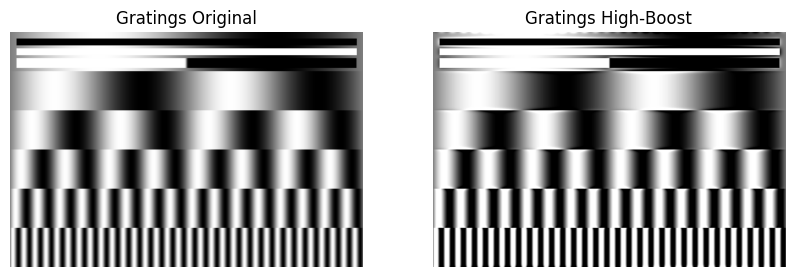

In [21]:
gratings_boost = highboost_fft(img_gratings, alpha=1.4, cutoff=25)
save_rgb('outputs/sample_gratings_highboost.jpg', gratings_boost)
show_pair(img_gratings, gratings_boost, ("Gratings Original", "Gratings High‑Boost"))

#### Run on Japan Image

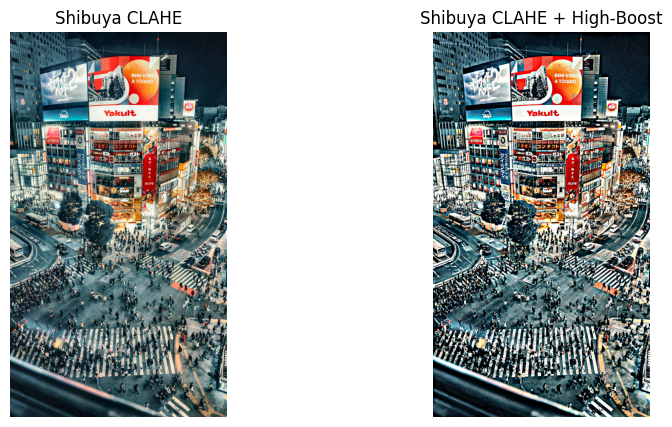

In [22]:
shibuya_clahe_boost = highboost_fft(shibuya_clahe, alpha=1.4, cutoff=25)
save_rgb('outputs/shibuya_CLAHE_highboost.jpg', shibuya_clahe_boost)
show_pair(shibuya_clahe, shibuya_clahe_boost, ("Shibuya CLAHE", "Shibuya CLAHE + High‑Boost"))

### Reinhard color transfer

In [23]:
def _lab_stats(lab: np.ndarray):
    # returns means and stds for (L, a, b)
    L, a, b = cv2.split(lab)
    def ms(x):
        x64 = x.astype(np.float64)
        return x64.mean(), x64.std(ddof=1) + 1e-6
    return [ms(L), ms(a), ms(b)]

In [24]:
def reinhard_color_transfer(target_rgb: np.ndarray, reference_rgb: np.ndarray) -> np.ndarray:
    tgt_lab = cv2.cvtColor(target_rgb, cv2.COLOR_RGB2LAB)
    ref_lab = cv2.cvtColor(reference_rgb, cv2.COLOR_RGB2LAB)
    (tL_m, tL_s), (ta_m, ta_s), (tb_m, tb_s) = _lab_stats(tgt_lab)
    (rL_m, rL_s), (ra_m, ra_s), (rb_m, rb_s) = _lab_stats(ref_lab)

    L, a, b = cv2.split(tgt_lab)
    L = ((L.astype(np.float64) - tL_m) * (rL_s / tL_s) + rL_m)
    a = ((a.astype(np.float64) - ta_m) * (ra_s / ta_s) + ra_m)
    b = ((b.astype(np.float64) - tb_m) * (rb_s / tb_s) + rb_m)

    L = np.clip(L, 0, 255).astype(np.uint8)
    a = np.clip(a, 0, 255).astype(np.uint8)
    b = np.clip(b, 0, 255).astype(np.uint8)

    lab2 = cv2.merge([L, a, b])
    out = cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)
    return out

#### Sample Image Test

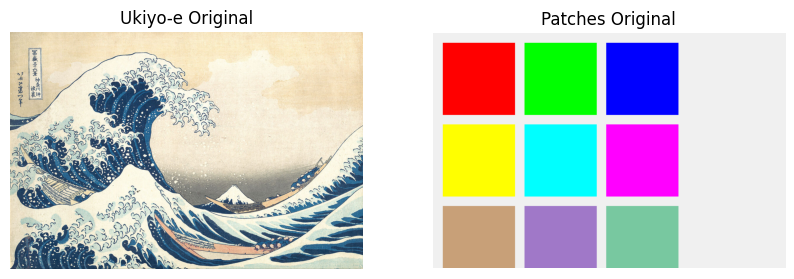

In [25]:
show_pair(img_ukiyoe, img_patches, ("Ukiyo-e Original", "Patches Original"))

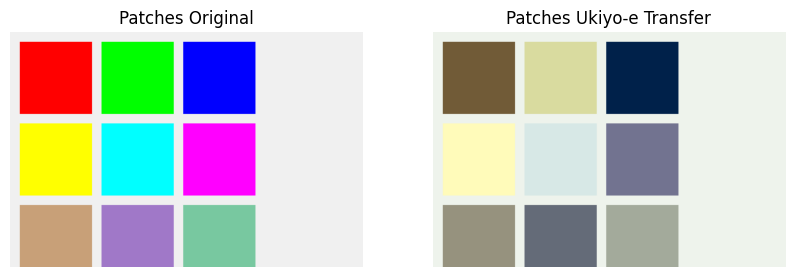

In [26]:
patches_transfer = reinhard_color_transfer(img_patches, img_ukiyoe)
save_rgb('outputs/sample_patches_UKIYOE_transfer.jpg', patches_transfer)
show_pair(img_patches, patches_transfer, ("Patches Original", "Patches Ukiyo‑e Transfer"))

#### Run on Japan Image

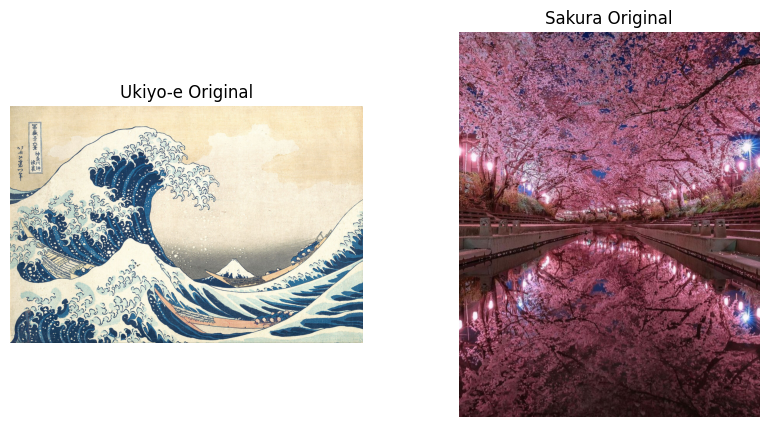

In [27]:
show_pair(img_ukiyoe, img_sakura, ("Ukiyo-e Original", "Sakura Original"))

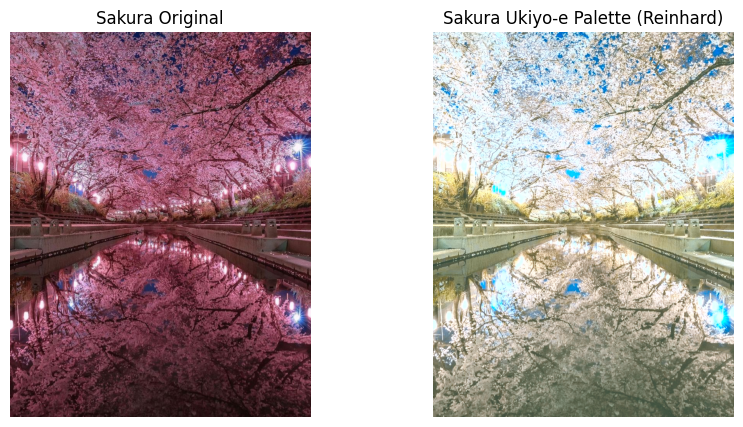

In [28]:
sakura_ukiyoe = reinhard_color_transfer(img_sakura, img_ukiyoe)
save_rgb('outputs/sakura_UKIYOE_transfer.jpg', sakura_ukiyoe)
show_pair(img_sakura, sakura_ukiyoe, ("Sakura Original", "Sakura Ukiyo‑e Palette (Reinhard)"))